# task 4 -> open set recognition on cifar-10

## imports

In [1]:
from pathlib import Path
import copy
import io
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as transforms
from torchvision.models import resnet18

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


SEED = 6304
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device {device}')

DATA_DIR = Path('./data')
OUTPUT_DIR = Path('./outputs/task4_osr')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
CACHE_DIR = OUTPUT_DIR / 'cache'
for directory in [DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

using device cuda


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## global env variables ->

In [2]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
NUM_KNOWN_CLASSES = 10
FEATURE_DIMENSION = 512

#unknown groups fixed by the assignment, 8 cifar-100 classes x 100 test imgs = 800 each
NEAR_UNKNOWN_CLASSES = ['bus', 'pickup_truck', 'motorcycle', 'tractor', 'wolf', 'fox', 'leopard', 'camel']
FAR_UNKNOWN_CLASSES = ['bottle', 'bowl', 'chair', 'clock', 'keyboard', 'mushroom', 'sunflower', 'wardrobe']

VALIDATION_FRACTION = 0.1

#hf parquet mirrors pinned to one commit each, torchvision pulls from cs.toronto.edu which is way too slow
CIFAR10_TRAIN_URL = ('https://huggingface.co/datasets/uoft-cs/cifar10/resolve/'
                     '0b2714987fa478483af9968de7c934580d0bb9a2/plain_text/train-00000-of-00001.parquet')
CIFAR10_TEST_URL = ('https://huggingface.co/datasets/uoft-cs/cifar10/resolve/'
                    '0b2714987fa478483af9968de7c934580d0bb9a2/plain_text/test-00000-of-00001.parquet')
CIFAR100_TEST_URL = ('https://huggingface.co/datasets/uoft-cs/cifar100/resolve/'
                     'aadb3af77e9048adbea6b47c21a81e47dd092ae5/cifar100/test-00000-of-00001.parquet')

#canonical alphabetical fine label order (parquet only has ints), assert guards it since unknowns are picked by name
CIFAR100_FINE_LABELS = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed',
    'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy',
    'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle',
    'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud',
    'cockroach', 'couch', 'cra', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl',
    'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower',
    'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree',
    'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange',
    'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit',
    'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
    'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail',
    'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper',
    'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale',
    'willow_tree', 'wolf', 'woman', 'worm',
]
assert len(CIFAR100_FINE_LABELS) == 100 and CIFAR100_FINE_LABELS == sorted(CIFAR100_FINE_LABELS)

NORMALIZATION_MEAN = (0.4914, 0.4822, 0.4465)
NORMALIZATION_STD = (0.2470, 0.2435, 0.2616)

BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
NUM_WORKERS = 4

RANDAUGMENT_NUM_OPS = 2
RANDAUGMENT_MAGNITUDE = 9

PROSER_EPOCHS = 50
PROSER_LEARNING_RATE = 1e-3
NUM_DUMMIES = 5
PROSER_BETA = 1.0
PROSER_GAMMA = 0.1
MIXUP_ALPHA = 2.0
PROSER_TEMPERATURE = 1024.0 #published reference temperature, not tuned

ACCEPT_PERCENTILE = 95 #threshold = 95th pct of val unknownness, known data only
MAHALANOBIS_EPSILON = 1e-6 #1e-6 floor on the diagonal before inverting

## cifar-10 loading and the 90/10 split

In [3]:
vanilla_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZATION_MEAN, NORMALIZATION_STD),
])

#only change -> randaugment after crop/flip, before totensor cuz it works on pil imgs
gcsc_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=RANDAUGMENT_NUM_OPS, magnitude=RANDAUGMENT_MAGNITUDE),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZATION_MEAN, NORMALIZATION_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZATION_MEAN, NORMALIZATION_STD),
])

class ParquetCIFAR(Dataset):
    #mimics the torchvision cifar surface (.targets .classes .class_to_idx) off the parquet
    def __init__(self, parquet_path, label_column, class_names, transform):
        frame = pd.read_parquet(parquet_path)
        self.images = list(frame['img'])
        self.targets = frame[label_column].tolist()
        self.classes = class_names
        self.class_to_idx = {name: index for index, name in enumerate(class_names)}
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, position):
        image = Image.open(io.BytesIO(self.images[position]['bytes'])).convert('RGB')
        return self.transform(image), int(self.targets[position])


def fetch(url, filename):
    path = DATA_DIR / filename
    if not path.exists():
        torch.hub.download_url_to_file(url, path)
    return path


cifar10_train_path = fetch(CIFAR10_TRAIN_URL, 'cifar10_train.parquet')
cifar10_test_path = fetch(CIFAR10_TEST_URL, 'cifar10_test.parquet')

cifar10_train_vanilla = ParquetCIFAR(cifar10_train_path, 'label', CIFAR10_CLASSES, vanilla_train_transform)
cifar10_train_gcsc = ParquetCIFAR(cifar10_train_path, 'label', CIFAR10_CLASSES, gcsc_train_transform)
cifar10_train_plain = ParquetCIFAR(cifar10_train_path, 'label', CIFAR10_CLASSES, eval_transform)
cifar10_test = ParquetCIFAR(cifar10_test_path, 'label', CIFAR10_CLASSES, eval_transform)
assert len(cifar10_train_vanilla) == 50000 and len(cifar10_test) == 10000

train_targets = np.asarray(cifar10_train_vanilla.targets)
train_indices, val_indices = train_test_split(
    np.arange(len(train_targets)), test_size=VALIDATION_FRACTION, stratify=train_targets, random_state=SEED
)

train_loader_vanilla = DataLoader(Subset(cifar10_train_vanilla, train_indices), batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), drop_last=False,
                                  persistent_workers=NUM_WORKERS > 0, generator=torch.Generator().manual_seed(SEED))
train_loader_gcsc = DataLoader(Subset(cifar10_train_gcsc, train_indices), batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), drop_last=False,
                               persistent_workers=NUM_WORKERS > 0, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(Subset(cifar10_train_plain, val_indices), batch_size=256, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(cifar10_test, batch_size=256, shuffle=False, num_workers=NUM_WORKERS)
train_plain_loader = DataLoader(Subset(cifar10_train_plain, train_indices), batch_size=256, shuffle=False, num_workers=NUM_WORKERS) #unaugmented, only for mahalanobis stats

print(f'train {len(train_indices)}  validation {len(val_indices)}  test {len(cifar10_test)}')

train 45000  validation 5000  test 10000


## the cifar resnet-18

In [4]:
class CifarResNet18(nn.Module):
    #cifar stem -> 3x3 stride 1 conv and no maxpool, the 224px stem throws away too much on 32x32
    def __init__(self, num_dummies=0):
        super().__init__()
        network = resnet18(weights=None)
        network.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        network.maxpool = nn.Identity()
        network.fc = nn.Identity() #head kept separate so the dummies share the feature
        self.network = network

        self.classifier = nn.Linear(FEATURE_DIMENSION, NUM_KNOWN_CLASSES)
        self.dummy_classifier = nn.Linear(FEATURE_DIMENSION, num_dummies) if num_dummies > 0 else None

    def features_through_layer2(self, images):
        #mixup goes on this output, after layer2 before layer3
        hidden = self.network.relu(self.network.bn1(self.network.conv1(images)))
        hidden = self.network.maxpool(hidden)
        hidden = self.network.layer1(hidden)
        return self.network.layer2(hidden) #(n, 128, 16, 16)

    def features_after_layer2(self, hidden):
        hidden = self.network.layer3(hidden)
        hidden = self.network.layer4(hidden)
        return self.network.avgpool(hidden).flatten(1) #(n, 512)

    def forward(self, images):
        feature = self.features_after_layer2(self.features_through_layer2(images))
        return feature, self.classifier(feature) #feature for mahalanobis, logits for the rest

## the shared training loop

In [5]:
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate_closed_set(model, loader):
    model.eval()
    correct = 0
    total = 0
    for images, labels in loader:
        _, logits = model(images.to(device, non_blocking=True))
        correct += (logits.argmax(dim=1).cpu() == labels).sum().item()
        total += labels.size(0)
    return 100 * correct / total


def train_closed_set(run_name, loader):
    #shared by vanilla and gcsc, only the loader/aug differs
    torch.manual_seed(SEED)
    model = CifarResNet18().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS) #cosine over the full 100 epochs

    history = []
    best_validation_accuracy = 0.0
    best_state = None
    best_epoch = 0
    run_start = time.time()

    for epoch in range(EPOCHS):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(loader, desc=f'{run_name} epoch {epoch + 1}', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()

            _, logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0) #weighted by batch size, last batch is smaller
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        validation_accuracy = evaluate_closed_set(model, val_loader)
        history.append({'run': run_name, 'epoch': epoch + 1, 'train_loss': running_loss / total,
                        'train_accuracy': 100 * correct / total, 'validation_accuracy': validation_accuracy,
                        'learning_rate': scheduler.get_last_lr()[0], 'epoch_seconds': time.time() - epoch_start})

        if validation_accuracy > best_validation_accuracy: #selection on cifar-10 val acc only
            best_validation_accuracy = validation_accuracy
            best_epoch = epoch + 1
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"{run_name} epoch {epoch + 1:03d}/{EPOCHS} | loss {history[-1]['train_loss']:.4f} | "
                  f"train {history[-1]['train_accuracy']:.2f}% | val {validation_accuracy:.2f}% | best {best_validation_accuracy:.2f}%")

    model.load_state_dict(best_state)
    torch.save(best_state, CHECKPOINT_DIR / f'{run_name}.pt')
    print(f'{run_name} best validation accuracy {best_validation_accuracy:.2f}% at epoch {best_epoch}')

    run_config = {'run': run_name, 'epochs': EPOCHS, 'learning_rate': LEARNING_RATE, 'momentum': MOMENTUM,
                  'weight_decay': WEIGHT_DECAY, 'batch_size': BATCH_SIZE, 'seed': SEED,
                  'best_epoch': best_epoch, 'best_validation_accuracy': best_validation_accuracy,
                  'seconds': time.time() - run_start}
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return model, pd.DataFrame(history), run_config

## experiment 1 : vanilla closed set baseline

In [6]:
#hypothesis -> plain ce has no 'none of the above', should be accurate on cifar-10 but confident on unknowns too
models = {}
histories = {}
run_configs = {}

models['vanilla'], histories['vanilla'], run_configs['vanilla'] = train_closed_set('vanilla', train_loader_vanilla)

vanilla epoch 1:   0%|          | 0/352 [00:00<?, ?it/s]

vanilla epoch 1:   0%|          | 1/352 [00:02<12:01,  2.05s/it]

vanilla epoch 1:   2%|▏         | 8/352 [00:02<01:09,  4.98it/s]

vanilla epoch 1:   5%|▍         | 16/352 [00:02<00:29, 11.29it/s]

vanilla epoch 1:   7%|▋         | 25/352 [00:02<00:16, 19.68it/s]

...

vanilla epoch 100:  91%|█████████ | 319/352 [00:03<00:00, 91.78it/s]

vanilla epoch 100:  93%|█████████▎| 329/352 [00:03<00:00, 91.71it/s]

vanilla epoch 100:  96%|█████████▋| 339/352 [00:03<00:00, 91.88it/s]

vanilla epoch 100:  99%|█████████▉| 349/352 [00:03<00:00, 92.84it/s]

vanilla epoch 100/100 | loss 0.0024 | train 99.98% | val 95.66% | best 95.76%
vanilla best validation accuracy 95.76% at epoch 95


## experiment 3 : gcsc, the same recipe plus randaugment

In [7]:
#hypothesis -> stronger aug raises csa but rejection may not follow, esp near (surer a wolf is a dog)
models['gcsc'], histories['gcsc'], run_configs['gcsc'] = train_closed_set('gcsc', train_loader_gcsc)

gcsc epoch 1:   0%|          | 0/352 [00:00<?, ?it/s]

gcsc epoch 1:   0%|          | 1/352 [00:00<04:42,  1.24it/s]

gcsc epoch 1:   3%|▎         | 11/352 [00:00<00:21, 15.89it/s]

gcsc epoch 1:   5%|▌         | 19/352 [00:01<00:12, 27.05it/s]

gcsc epoch 1:   7%|▋         | 26/352 [00:01<00:09, 34.92it/s]

...

gcsc epoch 100:  93%|█████████▎| 326/352 [00:05<00:00, 65.20it/s]

gcsc epoch 100:  95%|█████████▍| 334/352 [00:05<00:00, 65.34it/s]

gcsc epoch 100:  97%|█████████▋| 342/352 [00:05<00:00, 65.38it/s]

gcsc epoch 100:  99%|█████████▉| 350/352 [00:05<00:00, 65.59it/s]

gcsc epoch 100/100 | loss 0.0324 | train 98.98% | val 95.78% | best 95.86%
gcsc best validation accuracy 95.86% at epoch 91


## experiment 4 : proser, classifier and data placeholders

In [8]:
def augmented_logits(model, feature):
    return model.classifier(feature), model.dummy_classifier(feature) #(n, 10) and (n, 5)


def proser_losses(model, images, labels):
    #first half -> classifier placeholders, second half -> data placeholders (as the manual says)
    half = len(images) // 2
    classifier_images, classifier_labels = images[:half], labels[:half]
    mixup_images, mixup_labels = images[half:], labels[half:]

    #classifier placeholders
    feature = model.features_after_layer2(model.features_through_layer2(classifier_images))
    known_logits, dummy_logits = augmented_logits(model, feature)

    known_term = criterion(torch.cat([known_logits, dummy_logits], dim=1), classifier_labels)

    #true class masked, the strongest dummy (target index 10) has to win what remains
    masked_known = known_logits.clone()
    masked_known.scatter_(1, classifier_labels.view(-1, 1), -1e9) #-1e9 so the true class is unreachable
    strongest_dummy = dummy_logits.max(dim=1, keepdim=True).values
    dummy_target = torch.full_like(classifier_labels, NUM_KNOWN_CLASSES)
    placeholder_term = criterion(torch.cat([masked_known, strongest_dummy], dim=1), dummy_target)

    #data placeholders -> mixup bw two known classes after layer2, pushed towards the dummies
    hidden = model.features_through_layer2(mixup_images)
    permutation = torch.randperm(len(hidden), device=hidden.device)
    #y_i != y_j (manual requirement), same class mix would teach dummies to fire on normal knowns
    different_class = mixup_labels != mixup_labels[permutation]

    if different_class.any():
        mixing_weight = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)) #one lambda per step like the reference code
        mixed_hidden = mixing_weight * hidden[different_class] + (1 - mixing_weight) * hidden[permutation][different_class]
        mixed_feature = model.features_after_layer2(mixed_hidden)
        mixed_known, mixed_dummy = augmented_logits(model, mixed_feature)
        mixed_target = torch.full((len(mixed_feature),), NUM_KNOWN_CLASSES, device=images.device, dtype=torch.long)
        data_term = criterion(torch.cat([mixed_known, mixed_dummy.max(dim=1, keepdim=True).values], dim=1), mixed_target)
    else:
        data_term = torch.zeros((), device=images.device)

    return known_term, placeholder_term, data_term


def train_proser(vanilla_model):
    torch.manual_seed(SEED)
    model = CifarResNet18(num_dummies=NUM_DUMMIES).to(device)
    missing, unexpected = model.load_state_dict(vanilla_model.state_dict(), strict=False)
    #init from selected vanilla, only the two dummy tensors should be missing
    assert set(missing) == {'dummy_classifier.weight', 'dummy_classifier.bias'} and not unexpected, (missing, unexpected)

    optimizer = torch.optim.SGD(model.parameters(), lr=PROSER_LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PROSER_EPOCHS)

    history = []
    best_validation_accuracy = 0.0
    best_state = None
    best_epoch = 0
    run_start = time.time()

    for epoch in range(PROSER_EPOCHS):
        model.train()
        sums = np.zeros(3)
        batches = 0

        for images, labels in tqdm(train_loader_vanilla, desc=f'proser epoch {epoch + 1}', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()

            known_term, placeholder_term, data_term = proser_losses(model, images, labels)
            loss = known_term + PROSER_BETA * placeholder_term + PROSER_GAMMA * data_term #beta=1 gamma=0.1
            loss.backward()
            optimizer.step()

            sums += np.array([known_term.item(), placeholder_term.item(), data_term.item()])
            batches += 1

        scheduler.step()
        validation_accuracy = evaluate_closed_set(model, val_loader) #known logits only, dummies ignored
        history.append({'run': 'proser', 'epoch': epoch + 1, 'known_loss': sums[0] / batches,
                        'placeholder_loss': sums[1] / batches, 'data_placeholder_loss': sums[2] / batches,
                        'validation_accuracy': validation_accuracy, 'learning_rate': scheduler.get_last_lr()[0]})

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            best_epoch = epoch + 1
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"proser epoch {epoch + 1:03d}/{PROSER_EPOCHS} | known {history[-1]['known_loss']:.4f} | "
                  f"placeholder {history[-1]['placeholder_loss']:.4f} | data {history[-1]['data_placeholder_loss']:.4f} | "
                  f"val {validation_accuracy:.2f}%")

    model.load_state_dict(best_state)
    torch.save(best_state, CHECKPOINT_DIR / 'proser.pt')
    print(f'proser best validation accuracy {best_validation_accuracy:.2f}% at epoch {best_epoch}')

    run_config = {'run': 'proser', 'initialised_from': 'vanilla', 'epochs': PROSER_EPOCHS,
                  'learning_rate': PROSER_LEARNING_RATE, 'num_dummies': NUM_DUMMIES, 'beta': PROSER_BETA,
                  'gamma': PROSER_GAMMA, 'mixup_alpha': MIXUP_ALPHA, 'seed': SEED, 'best_epoch': best_epoch,
                  'best_validation_accuracy': best_validation_accuracy, 'seconds': time.time() - run_start}
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return model, pd.DataFrame(history), run_config


#hypothesis -> placeholders should improve rejection at little csa cost, far unknowns may gain less
#since mixup only covers the space bw known classes
models['proser'], histories['proser'], run_configs['proser'] = train_proser(models['vanilla'])

proser epoch 1:   0%|          | 0/352 [00:00<?, ?it/s]

proser epoch 1:   0%|          | 1/352 [00:00<04:22,  1.34it/s]

proser epoch 1:   1%|▏         | 5/352 [00:00<00:47,  7.31it/s]

proser epoch 1:   3%|▎         | 9/352 [00:00<00:27, 12.60it/s]

proser epoch 1:   4%|▍         | 15/352 [00:01<00:15, 21.40it/s]

...

proser epoch 50:  93%|█████████▎| 329/352 [00:05<00:00, 60.10it/s]

proser epoch 50:  95%|█████████▌| 336/352 [00:05<00:00, 60.24it/s]

proser epoch 50:  97%|█████████▋| 343/352 [00:05<00:00, 60.49it/s]

proser epoch 50:  99%|█████████▉| 350/352 [00:05<00:00, 61.61it/s]

proser epoch 050/50 | known 0.0085 | placeholder 0.0057 | data 0.0138 | val 89.70%
proser best validation accuracy 95.18% at epoch 4


## training curves and saved configurations

,run,best_epoch,best_validation_accuracy,seconds
0,vanilla,95,95.76,497.52
1,gcsc,91,95.86,638.25
2,proser,4,95.18,336.26


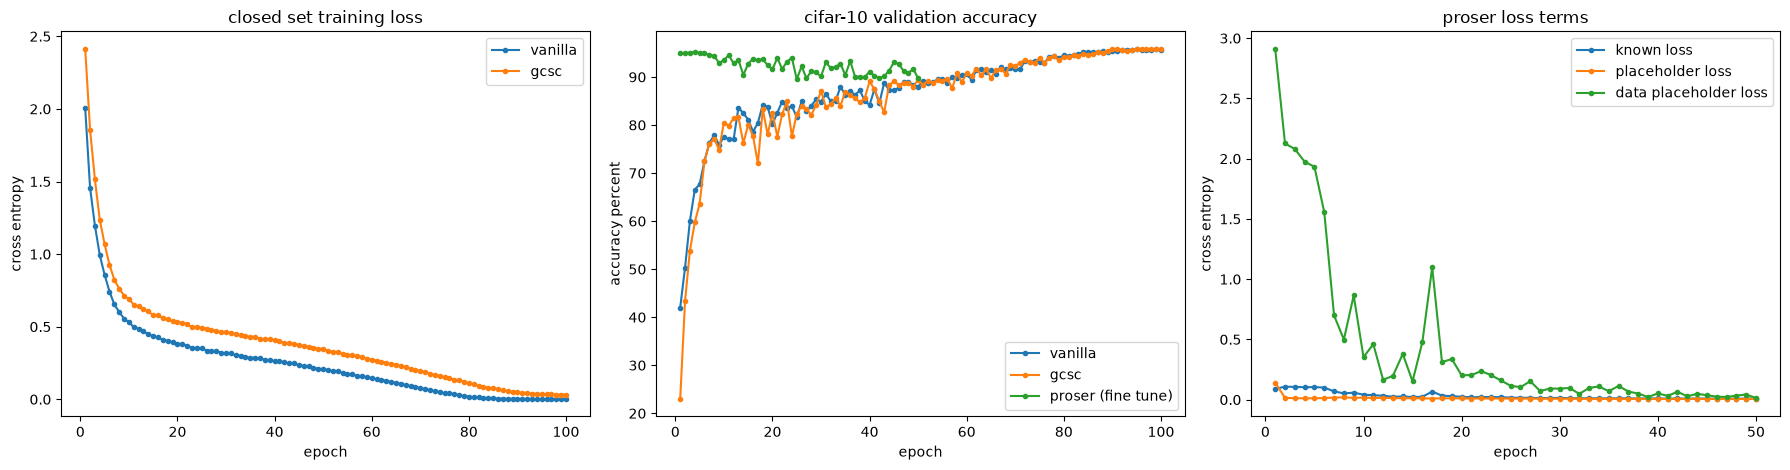

In [9]:
(OUTPUT_DIR / 'run_configs.json').write_text(json.dumps(run_configs, indent=1))
pd.concat(histories.values(), ignore_index=True).to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
display(pd.DataFrame(run_configs.values())[['run', 'best_epoch', 'best_validation_accuracy', 'seconds']].round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

for run_name in ['vanilla', 'gcsc']:
    axes[0].plot(histories[run_name]['epoch'], histories[run_name]['train_loss'], marker='.', label=run_name)
    axes[1].plot(histories[run_name]['epoch'], histories[run_name]['validation_accuracy'], marker='.', label=run_name)
axes[1].plot(histories['proser']['epoch'], histories['proser']['validation_accuracy'], marker='.', label='proser (fine tune)')

for column in ['known_loss', 'placeholder_loss', 'data_placeholder_loss']:
    axes[2].plot(histories['proser']['epoch'], histories['proser'][column], marker='.', label=column.replace('_', ' '))

for axis, title, y_label in [(axes[0], 'closed set training loss', 'cross entropy'),
                             (axes[1], 'cifar-10 validation accuracy', 'accuracy percent'),
                             (axes[2], 'proser loss terms', 'cross entropy')]:
    axis.set_title(title)
    axis.set_xlabel('epoch')
    axis.set_ylabel(y_label)
    axis.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

## locked evaluation -> all three checkpoints and every score definition are fixed, cifar-100 is loaded from here on

In [10]:
#cifar-100 only loaded now after the lock, test partition only (train is forbidden)
cifar100_test = ParquetCIFAR(fetch(CIFAR100_TEST_URL, 'cifar100_test.parquet'), 'fine_label',
                             CIFAR100_FINE_LABELS, eval_transform)
assert len(cifar100_test) == 10000

cifar100_targets = np.asarray(cifar100_test.targets)
def unknown_subset(class_names):
    wanted = [cifar100_test.class_to_idx[name] for name in class_names]
    rows = np.flatnonzero(np.isin(cifar100_targets, wanted))
    return Subset(cifar100_test, rows), rows

near_dataset, near_rows = unknown_subset(NEAR_UNKNOWN_CLASSES)
far_dataset, far_rows = unknown_subset(FAR_UNKNOWN_CLASSES)
assert len(near_dataset) == 800 and len(far_dataset) == 800, (len(near_dataset), len(far_dataset))

near_loader = DataLoader(near_dataset, batch_size=256, shuffle=False, num_workers=NUM_WORKERS)
far_loader = DataLoader(far_dataset, batch_size=256, shuffle=False, num_workers=NUM_WORKERS)
print(f'near unknowns {len(near_dataset)}  far unknowns {len(far_dataset)}')

  0%|          | 0.00/22.7M [00:00<?, ?B/s]

  1%|          | 128k/22.7M [00:00<01:35, 249kB/s]

 33%|███▎      | 7.38M/22.7M [00:00<00:00, 16.4MB/s]

 79%|███████▉  | 17.9M/22.7M [00:00<00:00, 38.0MB/s]

100%|██████████| 22.7M/22.7M [00:00<00:00, 30.1MB/s]

near unknowns 800  far unknowns 800


In [11]:
@torch.no_grad()
def extract_outputs(model, loader):
    #every score reads this one cache so they all see identical logits/features
    model.eval()
    features, logits, labels = [], [], []
    for images, batch_labels in loader:
        batch_features, batch_logits = model(images.to(device, non_blocking=True))
        features.append(batch_features.cpu())
        logits.append(batch_logits.cpu())
        labels.append(batch_labels)
    return {'features': torch.cat(features), 'logits': torch.cat(logits), 'labels': torch.cat(labels)}


evaluation_loaders = {'train': train_plain_loader, 'validation': val_loader, 'test': test_loader,
                      'near': near_loader, 'far': far_loader}

cached = {}
for run_name, model in models.items():
    model = model.to(device)
    cached[run_name] = {split: extract_outputs(model, loader) for split, loader in evaluation_loaders.items()}
    torch.save(cached[run_name], CACHE_DIR / f'{run_name}_outputs.pt')
    models[run_name] = model.cpu()

print('cifar-10 test accuracy')
for run_name in models: #csa always from the 10 known logits, proser incl
    outputs = cached[run_name]['test']
    print(f"  {run_name:8s} {100 * (outputs['logits'].argmax(dim=1) == outputs['labels']).float().mean():.2f}%")

cifar-10 test accuracy
  vanilla  94.88%
  gcsc     95.01%
  proser   94.30%


## the post hoc novelty scores

In [12]:
#every score = unknownness, bigger = more novel, so one threshold rule and auroc convention

def score_msp(outputs, statistics=None):
    return (1 - outputs['logits'].softmax(dim=1).max(dim=1).values).numpy()


def score_mls(outputs, statistics=None):
    return (-outputs['logits'].max(dim=1).values).numpy() #keeps the logit magnitude msp throws away (vaze et al)


def score_energy(outputs, statistics=None):
    return (-torch.logsumexp(outputs['logits'], dim=1)).numpy()


def fit_mahalanobis(train_outputs):
    #class means + one shared diagonal cov from unaugmented train features
    features = train_outputs['features']
    labels = train_outputs['labels']
    means = torch.stack([features[labels == class_index].mean(dim=0) for class_index in range(NUM_KNOWN_CLASSES)])

    centred = features - means[labels]
    variance = centred.pow(2).mean(dim=0) + MAHALANOBIS_EPSILON #pooled per dim variance + 1e-6 floor
    return {'means': means, 'inverse_variance': 1.0 / variance}


def score_mahalanobis(outputs, statistics):
    differences = outputs['features'].unsqueeze(1) - statistics['means'].unsqueeze(0) #(n, 10, 512)
    distances = (differences.pow(2) * statistics['inverse_variance']).sum(dim=2) #(n, 10)
    return distances.min(dim=1).values.numpy()


def score_proser_placeholder(outputs, statistics):
    #reference impl -> strongest dummy appended, softmax at T=1024, dummy prob - max known prob, bias fixed at 0
    model = statistics['model'].to(device)
    with torch.no_grad():
        dummy_logits = model.dummy_classifier(outputs['features'].to(device)).cpu()
    augmented = torch.cat([outputs['logits'], dummy_logits.max(dim=1, keepdim=True).values], dim=1)
    probabilities = (augmented / PROSER_TEMPERATURE).softmax(dim=1)
    model.cpu()
    return (probabilities[:, -1] - probabilities[:, :-1].max(dim=1).values).numpy()


mahalanobis_statistics = fit_mahalanobis(cached['vanilla']['train']) #fit once on vanilla train features
POSTHOC_SCORES = {'msp': score_msp, 'mls': score_mls, 'energy': score_energy, 'mahalanobis': score_mahalanobis}

## thresholds and the shared metric definitions

In [13]:
def evaluate_score(score_values):
    validation, test, near, far = (score_values[split] for split in ['validation', 'test', 'near', 'far'])
    all_unknown = np.concatenate([near, far])

    def auroc(unknown):
        return 100 * roc_auc_score(np.concatenate([np.zeros(len(test)), np.ones(len(unknown))]),
                                   np.concatenate([test, unknown]))

    threshold = float(np.percentile(validation, ACCEPT_PERCENTILE)) #95th pct of known val only

    return {
        'auroc_near': auroc(near), 'auroc_far': auroc(far), 'auroc_all': auroc(all_unknown),
        'threshold': threshold,
        'test_acceptance_rate': 100 * float((test <= threshold).mean()),
        'near_rejection_rate': 100 * float((near > threshold).mean()),
        'far_rejection_rate': 100 * float((far > threshold).mean()),
        'fpr_at_95tpr_near': 100 * float((near <= threshold).mean()), #unknowns let through at the same op point
        'fpr_at_95tpr_far': 100 * float((far <= threshold).mean()),
        'fpr_at_95tpr_all': 100 * float((all_unknown <= threshold).mean()),
    }


def closed_set_accuracy(run_name):
    outputs = cached[run_name]['test']
    return 100 * float((outputs['logits'].argmax(dim=1) == outputs['labels']).float().mean())


vanilla_scores = {}
for score_name, score_function in POSTHOC_SCORES.items():
    statistics = mahalanobis_statistics if score_name == 'mahalanobis' else None
    vanilla_scores[score_name] = {split: score_function(cached['vanilla'][split], statistics)
                                  for split in ['validation', 'test', 'near', 'far']}

posthoc_results = pd.DataFrame([{'score': score_name, 'closed_set_accuracy': closed_set_accuracy('vanilla'),
                                 **evaluate_score(values)} for score_name, values in vanilla_scores.items()])
posthoc_results.to_csv(OUTPUT_DIR / 'posthoc_scores_vanilla.csv', index=False)
display(posthoc_results.round(3))

,score,closed_set_accuracy,auroc_near,auroc_far,auroc_all,threshold,test_acceptance_rate,near_rejection_rate,far_rejection_rate,fpr_at_95tpr_near,fpr_at_95tpr_far,fpr_at_95tpr_all
0,msp,94.88,81.935,90.221,86.078,0.158,94.69,28.250,46.375,71.750,53.625,62.687
1,mls,94.88,80.398,90.001,85.200,-5.711,95.20,30.875,54.125,69.125,45.875,57.500
2,energy,94.88,80.413,90.085,85.249,-5.934,95.25,30.750,56.000,69.250,44.000,56.625
3,mahalanobis,94.88,79.844,92.432,86.138,2820.983,94.63,28.250,52.750,71.750,47.250,59.500


## vanilla against gcsc and proser

In [14]:
#mls on all three for a fair comparison, plus proser's own placeholder score
model_rows = []
model_scores = {}

for run_name in ['vanilla', 'gcsc', 'proser']:
    values = {split: score_mls(cached[run_name][split]) for split in ['validation', 'test', 'near', 'far']}
    model_scores[f'{run_name} mls'] = values
    model_rows.append({'model': run_name, 'score': 'mls', 'closed_set_accuracy': closed_set_accuracy(run_name),
                       **evaluate_score(values)})

placeholder_values = {split: score_proser_placeholder(cached['proser'][split], {'model': models['proser']})
                      for split in ['validation', 'test', 'near', 'far']}
model_scores['proser placeholder'] = placeholder_values
model_rows.append({'model': 'proser', 'score': 'placeholder', 'closed_set_accuracy': closed_set_accuracy('proser'),
                   **evaluate_score(placeholder_values)})

model_results = pd.DataFrame(model_rows)
model_results.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
display(model_results.round(3))

,model,score,closed_set_accuracy,auroc_near,auroc_far,auroc_all,threshold,test_acceptance_rate,near_rejection_rate,far_rejection_rate,fpr_at_95tpr_near,fpr_at_95tpr_far,fpr_at_95tpr_all
0,vanilla,mls,94.88,80.398,90.001,85.200,-5.711,95.20,30.875,54.125,69.125,45.875,57.500
1,gcsc,mls,95.01,80.625,91.392,86.009,-5.877,95.20,32.750,59.375,67.250,40.625,53.938
2,proser,mls,94.30,79.832,88.667,84.250,-5.059,94.91,28.000,51.375,72.000,48.625,60.312
3,proser,placeholder,94.30,77.868,89.072,83.470,0.000,94.80,25.625,51.000,74.375,49.000,61.687


## score distributions and roc curves

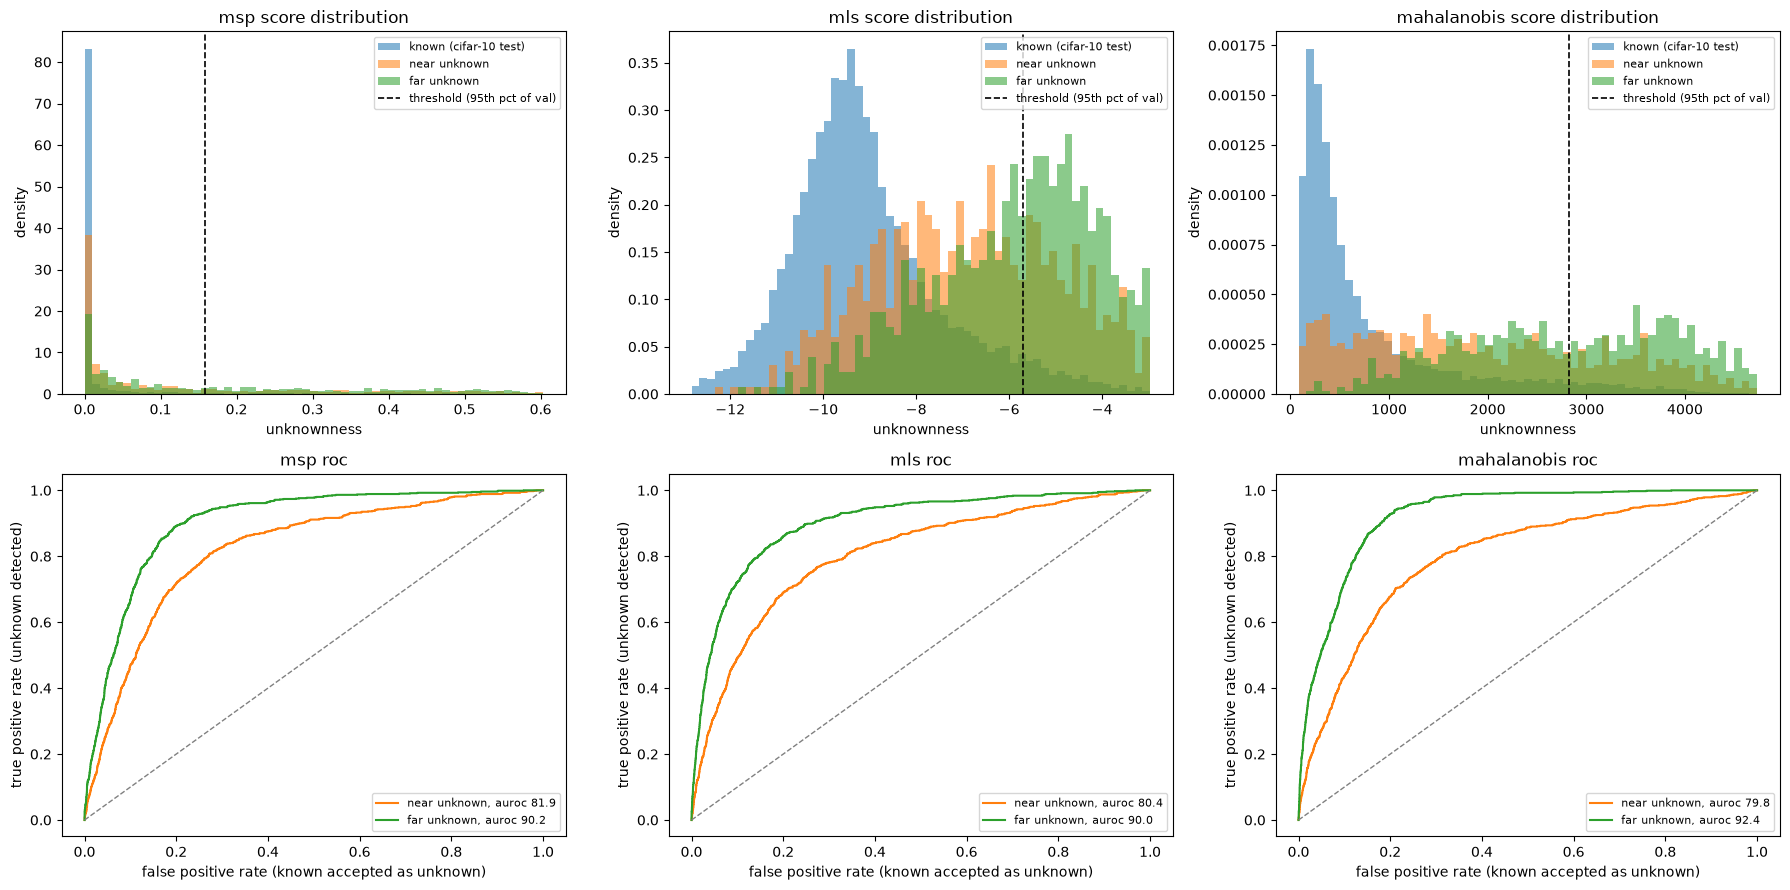

In [15]:
#score distributions vs threshold (top), roc (bottom)
figure_scores = ['msp', 'mls', 'mahalanobis']
fig, axes = plt.subplots(2, len(figure_scores), figsize=(18, 9))

for column, score_name in enumerate(figure_scores):
    values = vanilla_scores[score_name]
    threshold = float(np.percentile(values['validation'], ACCEPT_PERCENTILE))

    combined = np.concatenate([values['test'], values['near'], values['far']])
    bins = np.linspace(np.percentile(combined, 0.5), np.percentile(combined, 99.5), 60)
    for split, colour in [('test', 'tab:blue'), ('near', 'tab:orange'), ('far', 'tab:green')]:
        axes[0, column].hist(values[split], bins=bins, alpha=0.55, density=True, color=colour, #density cuz 10k known vs 800 per unknown group
                             label={'test': 'known (cifar-10 test)', 'near': 'near unknown', 'far': 'far unknown'}[split])
    axes[0, column].axvline(threshold, color='black', linestyle='--', linewidth=1.2, label='threshold (95th pct of val)')
    axes[0, column].set_title(f'{score_name} score distribution')
    axes[0, column].set_xlabel('unknownness')
    axes[0, column].set_ylabel('density')
    axes[0, column].legend(fontsize=8)

    for split, colour in [('near', 'tab:orange'), ('far', 'tab:green')]:
        binary = np.concatenate([np.zeros(len(values['test'])), np.ones(len(values[split]))])
        false_positive, true_positive, _ = roc_curve(binary, np.concatenate([values['test'], values[split]]))
        area = 100 * roc_auc_score(binary, np.concatenate([values['test'], values[split]]))
        axes[1, column].plot(false_positive, true_positive, color=colour, label=f'{split} unknown, auroc {area:.1f}')
    axes[1, column].plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1) #chance
    axes[1, column].set_title(f'{score_name} roc')
    axes[1, column].set_xlabel('false positive rate (known accepted as unknown)')
    axes[1, column].set_ylabel('true positive rate (unknown detected)')
    axes[1, column].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'score_distributions_and_roc.png', dpi=180, bbox_inches='tight')
plt.show()

## failure analysis at the vanilla mls threshold

near unknowns wrongly accepted: 553 of 800
far unknowns wrongly accepted: 367 of 800


,group,unknown_class,predicted_known_class,unknownness_score,threshold
0,near,wolf,dog,-7.5666,-5.7109
1,near,tractor,truck,-7.7919,-5.7109
2,near,pickup_truck,automobile,-6.7769,-5.7109
3,far,mushroom,cat,-11.0680,-5.7109
4,far,bowl,frog,-9.6933,-5.7109
5,far,wardrobe,truck,-5.8391,-5.7109


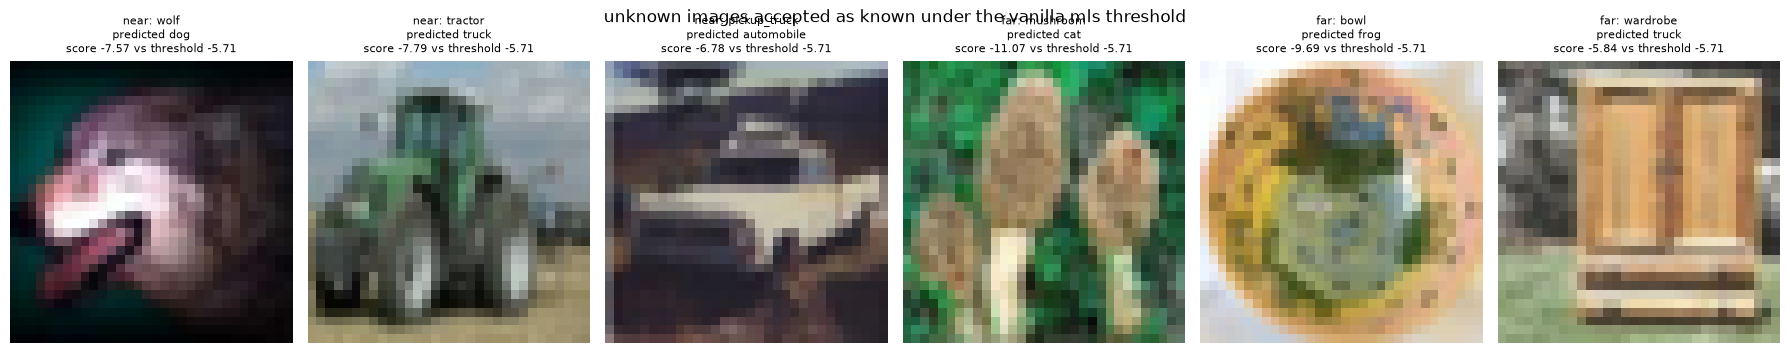

group,far,near
known_class,,
airplane,50,12
automobile,9,99
bird,74,18
cat,80,104
deer,3,42
dog,17,65
frog,26,32
horse,3,18
ship,39,8


In [16]:
#wrongly accepted unknowns, >=3 per group w/ class, prediction, score and threshold
mls_values = vanilla_scores['mls']
mls_threshold = float(np.percentile(mls_values['validation'], ACCEPT_PERCENTILE))
examples_per_group = 3

failure_rows = []
failure_images = []
for group_name, rows, loader_dataset in [('near', near_rows, near_dataset), ('far', far_rows, far_dataset)]:
    values = mls_values[group_name]
    accepted = np.flatnonzero(values <= mls_threshold) #wrongly accepted
    chosen = np.random.default_rng(SEED).permutation(accepted)[:examples_per_group] #seeded shuffle, not picked by hand
    predictions = cached['vanilla'][group_name]['logits'].argmax(dim=1).numpy()

    for position in chosen:
        failure_rows.append({
            'group': group_name,
            'unknown_class': cifar100_test.classes[cifar100_targets[rows[position]]],
            'predicted_known_class': CIFAR10_CLASSES[predictions[position]],
            'unknownness_score': float(values[position]),
            'threshold': mls_threshold,
        })
        failure_images.append(loader_dataset[position][0])

    print(f'{group_name} unknowns wrongly accepted: {len(accepted)} of {len(values)}')

failures = pd.DataFrame(failure_rows)
failures.to_csv(OUTPUT_DIR / 'accepted_unknown_failures.csv', index=False)
display(failures.round(4))

#reverses normalisation for visuals
mean = torch.tensor(NORMALIZATION_MEAN).view(3, 1, 1)
std = torch.tensor(NORMALIZATION_STD).view(3, 1, 1)

fig, axes = plt.subplots(1, len(failure_images), figsize=(3 * len(failure_images), 3.6))
for axis, image, (_, row) in zip(axes, failure_images, failures.iterrows()):
    axis.imshow((image * std + mean).clamp(0, 1).permute(1, 2, 0))
    axis.set_title(f"{row['group']}: {row['unknown_class']}\npredicted {row['predicted_known_class']}\n"
                   f"score {row['unknownness_score']:.2f} vs threshold {mls_threshold:.2f}", fontsize=8)
    axis.axis('off')

plt.suptitle('unknown images accepted as known under the vanilla mls threshold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'accepted_unknown_failures.png', dpi=180, bbox_inches='tight')
plt.show()

#which cifar-10 labels absorb the unknowns (rq1)
absorption_rows = []
for group_name in ['near', 'far']:
    values = mls_values[group_name]
    predictions = cached['vanilla'][group_name]['logits'].argmax(dim=1).numpy()
    accepted = values <= mls_threshold
    for class_index, class_name in enumerate(CIFAR10_CLASSES):
        absorption_rows.append({'group': group_name, 'known_class': class_name,
                                'accepted_unknowns': int(((predictions == class_index) & accepted).sum())})

absorption = pd.DataFrame(absorption_rows).pivot(index='known_class', columns='group', values='accepted_unknowns')
absorption.to_csv(OUTPUT_DIR / 'unknown_absorption_by_class.csv')
display(absorption)

if torch.cuda.is_available():
    torch.cuda.empty_cache()